In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
# Some sample data points to interpolate
X = np.array([4, 5, 7, 8])
Y = np.array([3, 5, 4.5, 7])

# Dense sampling along the x-axis for reconstruction
newX = np.linspace(4, 8, 50)

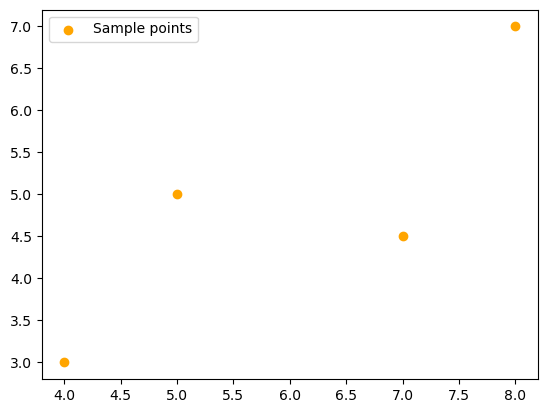

In [3]:
# Show the data points
plt.scatter(X, Y, color="orange", label='Sample points') # or use plot()
plt.legend()
plt.show()

Now define the basis functions to be used, e.g. powers of a polynomial.

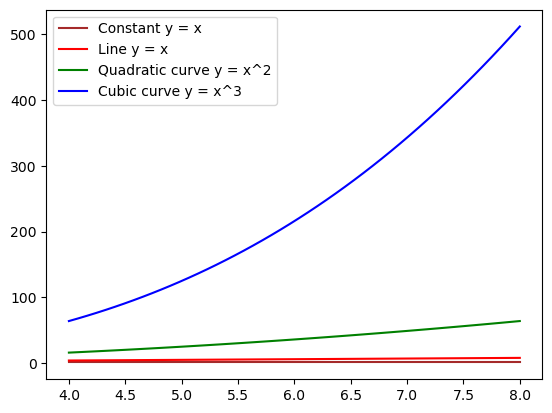

In [4]:
# Now define the basis functions to be used, e.g. polynomials of degree k.
def FuncXk(X,k):
    return X**k

plt.plot(newX, FuncXk(newX, 0), color="brown", label='Constant y = x')
plt.plot(newX, FuncXk(newX, 1), color="red",   label='Line y = x')
plt.plot(newX, FuncXk(newX, 2), color="green", label='Quadratic curve y = x^2')
plt.plot(newX, FuncXk(newX, 3), color="blue",  label='Cubic curve y = x^3')
plt.legend()
plt.show()

Want to find $Ac = Y$, with $A$ being the function values of $1, x, x^2, x^3$. So need to fill $A$ with these columns, and then solve for $c = A^{-1}\ Y$.

In [5]:
A = np.array([FuncXk(X,0), FuncXk(X,1), FuncXk(X,2), FuncXk(X,3)]).T # transposed into column form
A

array([[  1,   4,  16,  64],
       [  1,   5,  25, 125],
       [  1,   7,  49, 343],
       [  1,   8,  64, 512]])

In [6]:
c = np.linalg.inv(A).dot(Y)
c

array([-78.33333333,  43.33333333,  -7.41666667,   0.41666667])

Ok, now we should test if the functions $1, x, x^2, x^3$ with coefficients $c$ actually create the original curve. For this we compute the linear combination from the coefficients of $c$ and the basis functions applied to the input values of the array $X$.

In [7]:
def testFunc(c, newX):
    A = np.array([FuncXk(newX,0), FuncXk(newX,1), FuncXk(newX,2), FuncXk(newX,3)]).T
    return A.dot(c)

In [8]:
testFunc(c,X)

array([3. , 5. , 4.5, 7. ])

Now apply the interpolation function (myFunc) to a new set of input values and plot it.

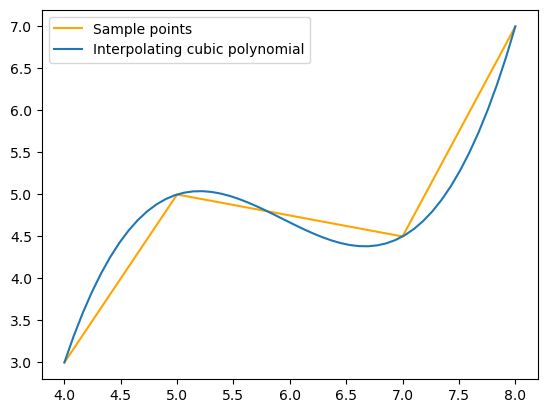

In [9]:
newY = testFunc(c, newX)
plt.plot(X, Y, color="orange", label='Sample points')
plt.plot(newX, newY,           label='Interpolating cubic polynomial')
plt.legend()
plt.show()

Now try some other basis functions e.g. using sine, cosine or exponential functions.

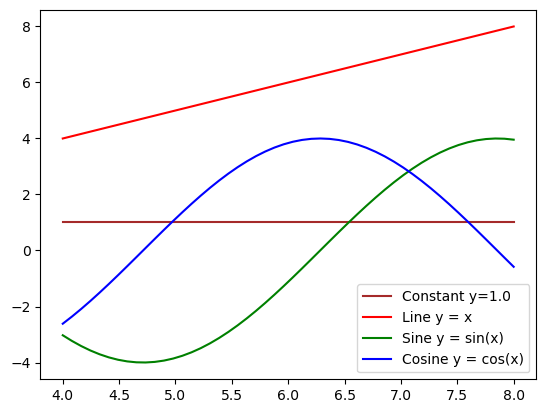

In [10]:
def FuncS(X):
    return np.sin(X)*4
def FuncC(X):
    return np.cos(X)*4
plt.plot(newX, FuncXk(newX, 0), color="brown", label='Constant y=1.0')
plt.plot(newX, FuncXk(newX, 1), color="red",   label='Line y = x')
plt.plot(newX, FuncS(newX), color="green",     label='Sine y = sin(x)')
plt.plot(newX, FuncC(newX), color="blue",      label='Cosine y = cos(x)')
plt.legend()
plt.show()

In [ ]:
def testFunc2(c, newX):
    A = np.array([FuncXk(newX,0), FuncXk(newX,1), FuncS(newX), FuncC(newX)]).T
    return A.dot(c)

In [ ]:
A = np.array([FuncXk(X,0), FuncXk(X,1), FuncS(X), FuncC(X)]).T # transposed into column form
c = np.linalg.inv(A).dot(Y)
newY = testFunc2(c, newX)
plt.plot(X, Y, color="orange", label='Sample points')
plt.plot(newX, newY,           label='Interpolating with sine and cosine')
plt.legend()
plt.show()

Try some other functions ...

In [ ]:
def FuncE(X):
    return np.exp(X)*0.005
plt.plot(newX, FuncXk(newX, 0), color="brown", label='Constant y=1.0')
plt.plot(newX, FuncXk(newX, 1), color="red",   label='Line y = x')
plt.plot(newX, FuncC(newX), color="green",     label='Cosine y = cos(x)')
plt.plot(newX, FuncE(newX), color="blue",      label='Exponential y = e^x')
plt.legend()
plt.show()

In [ ]:
def testFunc3(c, newX):
    A = np.array([FuncXk(newX,0), FuncXk(newX,1), FuncC(newX), FuncE(newX)]).T
    return A.dot(c)

In [ ]:
A = np.array([FuncXk(X,0), FuncXk(X,1), FuncC(X), FuncE(X)]).T # transposed into column form
c = np.linalg.inv(A).dot(Y)
newY = testFunc3(c, newX)
plt.plot(X, Y, color="orange", label='Sample points')
plt.plot(newX, newY,           label='Interpolating with cosine and exponential')
plt.legend()
plt.show()